# 01 — Diagnóstico del PDF
Antes de escribir un parser: ¿el PDF tiene texto o hace falta OCR? ¿qué páginas están vacías?
¿cómo se rotulan los cuadros? No escribe nada en `data/`.

In [1]:
%run -i modulos/comun.ipynb
import re
from collections import Counter
import matplotlib.pyplot as plt

UMBRAL_VACIA = 60   # caracteres; por debajo, la página es un mapa o una imagen


def ejecutar(cmd):
    res = subprocess.run(cmd, capture_output=True, text=True, errors="replace")
    if res.returncode != 0:
        raise RuntimeError("Falló " + " ".join(cmd) + ":\n" + res.stderr)
    return res.stdout


def texto_pagina(n):
    return ejecutar(["pdftotext", "-layout", "-f", str(n), "-l", str(n), str(PDF), "-"])

## Metadatos

In [2]:
meta = ejecutar(["pdfinfo", str(PDF)])
print(meta.strip())
n_paginas = int(re.search(r"^Pages:\s+(\d+)", meta, re.M).group(1))

Creator:         PDF24 Creator
Producer:        GPL Ghostscript 9.56.1
CreationDate:    Wed May  8 16:44:04 2024 -04
ModDate:         Wed May  8 16:44:04 2024 -04
Custom Metadata: no
Metadata Stream: yes
Tagged:          no
UserProperties:  no
Suspects:        no
Form:            none
JavaScript:      no
Pages:           774
Encrypted:       no
Page size:       1650 x 1275 pts
Page rot:        0
File size:       42905977 bytes
Optimized:       no
PDF version:     1.7


## Capa de texto

In [3]:
completo = ejecutar(["pdftotext", "-layout", str(PDF), "-"])
pags = completo.split("\f")
if len(pags) > 0 and pags[-1] == "":
    pags.pop()

caracteres = []
for p in pags:
    caracteres.append(len(p.strip()))
total_chars = sum(caracteres)

print("Páginas según pdfinfo  :", n_paginas)
print("Páginas según pdftotext:", len(pags))
print("Caracteres extraídos   :", total_chars)
print("Promedio por página    :", total_chars // len(pags))
if total_chars > 100000:
    print("Veredicto: hay capa de texto, NO se necesita OCR.")
else:
    print("Veredicto: capa de texto insuficiente, revisar.")

Páginas según pdfinfo  : 774
Páginas según pdftotext: 774
Caracteres extraídos   : 5439477
Promedio por página    : 7027
Veredicto: hay capa de texto, NO se necesita OCR.


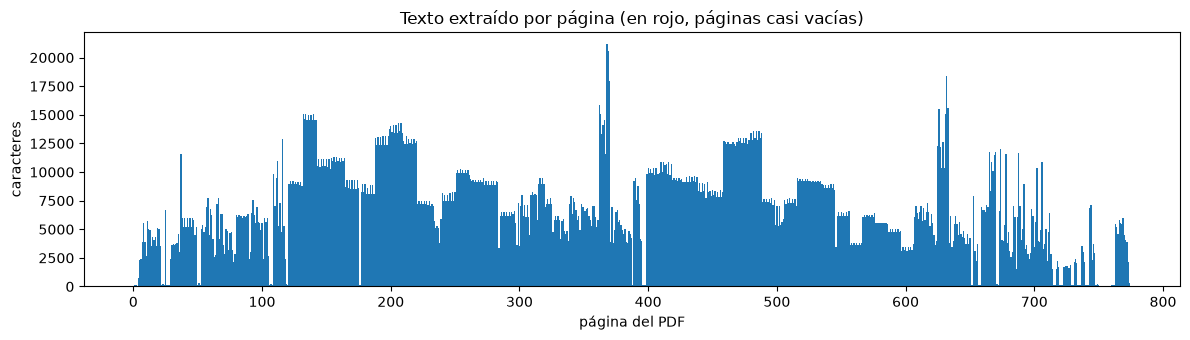

In [4]:
colores = []
for c in caracteres:
    if c < UMBRAL_VACIA:
        colores.append("tab:red")
    else:
        colores.append("tab:blue")
plt.figure(figsize=(12, 3.5))
plt.bar(range(1, len(pags) + 1), caracteres, color=colores, width=1.0)
plt.xlabel("página del PDF")
plt.ylabel("caracteres")
plt.title("Texto extraído por página (en rojo, páginas casi vacías)")
plt.tight_layout()
plt.show()

## Páginas casi vacías

In [5]:
vacias = []
for i in range(len(pags)):
    if caracteres[i] < UMBRAL_VACIA:
        vacias.append(i + 1)
print("Total:", len(vacias))
for pag in vacias:
    muestra = " ".join(pags[pag - 1].split())[:50]
    print("  pág.", pag, " ", caracteres[pag - 1], "chars ", repr(muestra))

Total: 10
  pág. 3   0 chars  ''
  pág. 751   0 chars  ''
  pág. 752   0 chars  ''
  pág. 753   0 chars  ''
  pág. 754   0 chars  ''
  pág. 755   0 chars  ''
  pág. 756   0 chars  ''
  pág. 757   0 chars  ''
  pág. 758   0 chars  ''
  pág. 759   0 chars  ''


## Literales de navegación: "Cuadro Nro." y "Gráfica Nro."

In [6]:
pat_cuadro = re.compile(r"Cuadro\s+Nro\.", re.I)
pat_grafica = re.compile(r"Gr[áa]fica\s+Nro\.", re.I)
pags_cuadro = []
pags_grafica = []
for i in range(len(pags)):
    if pat_cuadro.search(pags[i]):
        pags_cuadro.append(i + 1)
    if pat_grafica.search(pags[i]):
        pags_grafica.append(i + 1)
print("Páginas con 'Cuadro Nro.' :", len(pags_cuadro))
print("Páginas con 'Gráfica Nro.':", len(pags_grafica))
solapan = sorted(set(pags_cuadro) & set(pags_grafica))
print("Páginas con ambos literales:", len(solapan), solapan[:20])

ids = re.findall(r"Cuadro\s+Nro\.\s*([0-9]+(?:\.[0-9]+)*)", completo, re.I)
print("IDs de cuadro capturados:", len(ids), "(", len(set(ids)), "únicos)")
repetidos = []
for k, v in Counter(ids).items():
    if v > 1:
        repetidos.append(k)
print("IDs repetidos (mismo cuadro en más de una página):", len(repetidos), sorted(repetidos)[:15])

Páginas con 'Cuadro Nro.' : 604
Páginas con 'Gráfica Nro.': 30
Páginas con ambos literales: 0 []
IDs de cuadro capturados: 604 ( 156 únicos)
IDs repetidos (mismo cuadro en más de una página): 91 ['14.1.1', '2.1.1.2', '2.1.2.1', '3.1.1.1', '3.1.1.2', '3.1.2.1', '3.1.2.2', '3.1.3.1', '3.1.3.2', '3.1.4.1', '3.1.4.2', '3.1.5.1', '3.1.5.2', '3.1.6.1', '3.1.6.2']


## Muestras crudas: página 673 (cuadro 9.1.1) y 737 (cuadro 13.1.1)

In [7]:
print(texto_pagina(673))

Órgano Judicial de Bolivia                                                                                                                                                                                                Consejo de la Magistratura
                                                                                                                                                                                                Jefatura Nacional de Estudios Técnicos y Estadísticos



                                                                    RESUMEN ANUARIO ESTADÍSTICO JUDICIAL
Cuadro Nro. 9.1.1
GESTIÓN 2023
MOVIMIENTO DE CAUSAS EN CIUDADES CAPITALES
Por: Materia

                                                                                                                                                                                                    % DE CAUSAS      PROMEDIO DE
                                                                                    NÚME

In [8]:
print(texto_pagina(737)[:2500])

                                                     Autoridad Sumariante
Cuadro Nro. 13.1.1
Gestión 2023
PROCESOS SUMARIOS
Por:                 Distrito
Según:               Movimiento Registrado


                         DENUNCIAS
                                                DENUNCIAS             TOTAL DENUNCIAS RESOLUCIONES EN                                       PROCESOS EN
         DISTRITO    PENDIENTES AL INICIO                                                                                 RECHAZADAS
                         DE GESTIÓN             RECIBIDAS                ATENDIDAS    PRIMERA INSTANCIA                                       TRAMITE


OFICINA NACIONAL             39                      57                       96                            61                18                 17
CHUQUISACA                    5                       7                       12                             8                0                  4
LA PAZ                        0   